## Regularization - Weights & Biases decay
The goal of this notebook is to test the effect of regularization, in terms of weight and bias decay, on the performance of the SGD optimizer on a linear regression problem.
We will use a synthetic dataset generated from a known linear signal `f(x) = SLOPE*x + INTERCEPT`, with independent Gaussian noise added at a fixed level to produce several noisy realizations of the same underlying relationship.

In [111]:
import numpy as np

SLOPE = 3.23
INTERCEPT = 7.6

"""Signal to estimate"""
def f(x: np.ndarray) -> np.ndarray:
    return x*SLOPE + INTERCEPT

COEFS = np.array([[SLOPE], [INTERCEPT]])

In [112]:
from examples.linear_regression.helpers.dataset import generate_noise_dataset, split_dataset, preprocess_dataloader

SEED = 888
NOISE = 100
MIN = -7
MAX = 7
SAMPLE_SIZE = 100
BATCH_SIZE = 16

viz_sample = generate_noise_dataset(f, size=1, sample_size=SAMPLE_SIZE, noise=NOISE, min=MIN, max=MAX, seed=SEED)[0]
X_viz, y_viz = viz_sample[:, 0], viz_sample[:, 1]


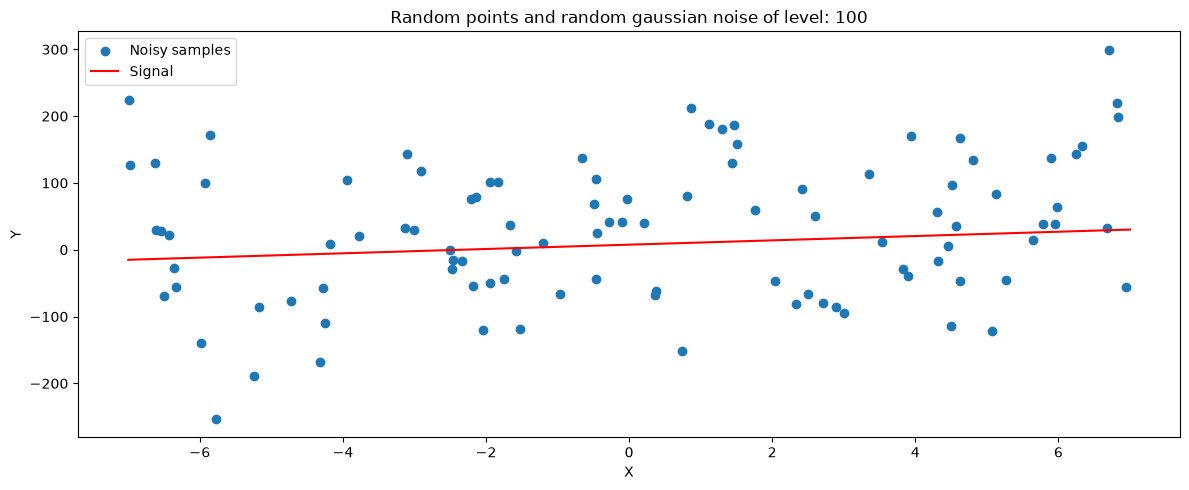

In [113]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax) = plt.subplots(1, 1, figsize=(12, 5))

x_line = np.linspace(MIN, MAX, 200)

ax.scatter(X_viz, y_viz, label="Noisy samples")
ax.plot(x_line, f(x_line), color="red", label="Signal")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title(f"Random points and random gaussian noise of level: {NOISE}")
ax.legend()

fig.tight_layout()
plt.show()

## Training: decay in isolation

This experiment comprises three different scenarios:

0. No Variance at all, same dataset, very little noise

1. No weight decay

2. Weight decay:
   - 1 dimension for the decay coefficients, with increasing decay coefficients

3. Weight decay + Bias decay:
   - 1 dimension for the decay coefficients, with increasing decay coefficients

## 1. No weight decay

In this scenario we train the model without any weight decay, and evaluate its performance on the test set. We use a learning rate scheduler and the SGD optimizer.
We also plot the training and validation loss curves to visualize the performance of the model.

In [114]:
"""Training over N_TRIALS independent noisy realizations of the same signal f(x), at the same fixed NOISE level, one trainer fitting each, to observe how weights and biases vary with a high variance dataset."""

from core.training.trainer import Trainer
from examples.linear_regression.helpers.train import create_trainer, fit_model

EPOCHS = 80
N_TRIALS = 2
EVAL_STEP = 10
MAX_LR, MIN_LR = 1e-2, 1e-4
IN_FEATURE, OUT_FEATURE = 1, 1

repeats = generate_noise_dataset(f, N_TRIALS, SAMPLE_SIZE, NOISE, MIN, MAX, SEED)
tr, te = split_dataset(repeats, split_ratio=0.9, axis=1)

fitted_trainers:list[Trainer] = []

for sample_tr, sample_te in zip(tr, te):
    loader_tr, loader_te = preprocess_dataloader(sample_tr, sample_te, BATCH_SIZE)
    trainer = create_trainer(IN_FEATURE, OUT_FEATURE, MIN_LR, MAX_LR, EPOCHS)
    fit_model(trainer, loader_tr, loader_te, EPOCHS, EVAL_STEP)
    fitted_trainers.append(trainer)


## Loss history and weights interpretation

The loss histories are plotted for each trial on the same graph, with train and evaluation loss shown in separate plots. The learned weights and biases are also visualized to understand the impact of a high-variance dataset on the spread of parameters across trials.

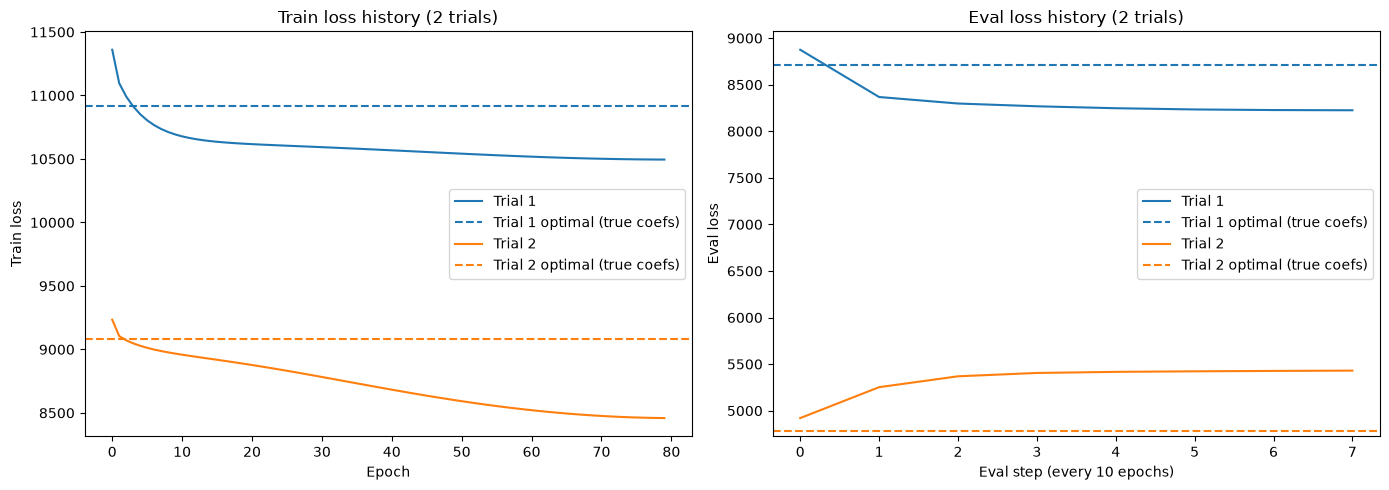

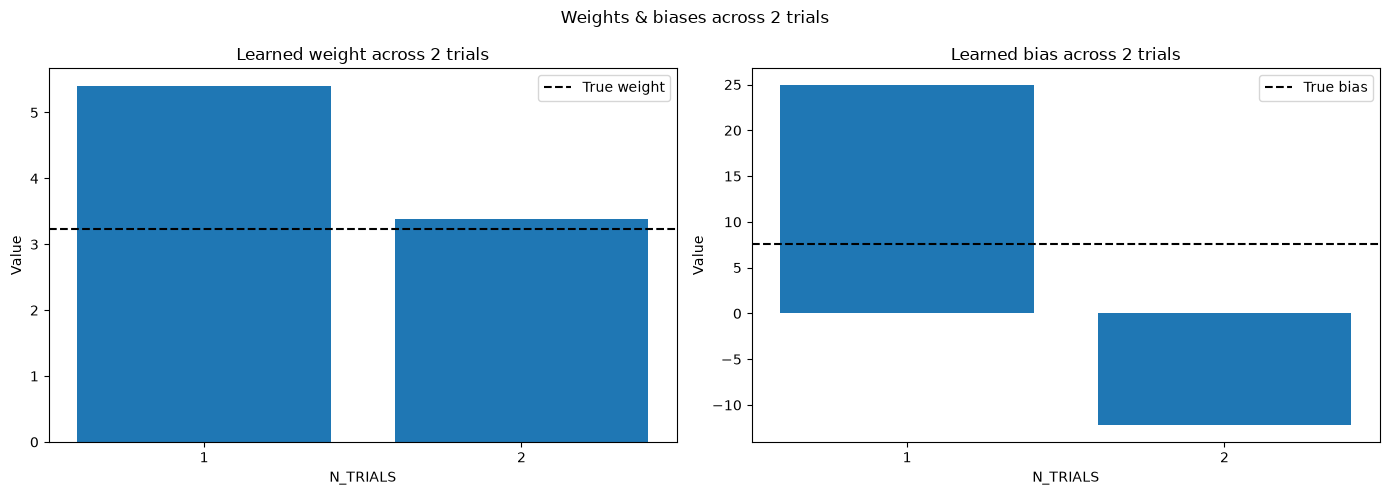

In [115]:
import matplotlib.pyplot as plt
from core.functions import mse
from examples.linear_regression.helpers.train import get_models_params


params_history = get_models_params([trainer.model for trainer in fitted_trainers])
weights_history = np.array([p[0].flatten()[0] for p in params_history])
bias_history = np.array([p[1].flatten()[0] for p in params_history])

fig, (ax_train, ax_eval) = plt.subplots(1, 2, figsize=(14, 5))

for i, trainer in enumerate(fitted_trainers):
    line, = ax_train.plot(trainer.train_loss, label=f"Trial {i+1}")

    closed_form_loss_tr = mse(f(tr[i][:, 0]), tr[i][:, 1])
    ax_train.axhline(closed_form_loss_tr, color=line.get_color(), linestyle="dashed", label=f"Trial {i+1} optimal (true coefs)")
ax_train.set_xlabel("Epoch")
ax_train.set_ylabel("Train loss")
ax_train.set_title(f"Train loss history ({N_TRIALS} trials)")
ax_train.legend()

for i, trainer in enumerate(fitted_trainers):
    line, = ax_eval.plot(trainer.eval_loss, label=f"Trial {i+1}")

    closed_form_loss_te = mse(f(te[i][:, 0]), te[i][:, 1])
    ax_eval.axhline(closed_form_loss_te, color=line.get_color(), linestyle="dashed", label=f"Trial {i+1} optimal (true coefs)")
ax_eval.set_xlabel(f"Eval step (every {EVAL_STEP} epochs)")
ax_eval.set_ylabel("Eval loss")
ax_eval.set_title(f"Eval loss history ({N_TRIALS} trials)")
ax_eval.legend()

fig.tight_layout()
plt.show()

trials = np.arange(1, N_TRIALS + 1)

fig, (ax_w, ax_b) = plt.subplots(1, 2, figsize=(14, 5))

ax_w.bar(trials, weights_history)
ax_w.axhline(SLOPE, color="black", linestyle="dashed", label="True weight")
ax_w.set_xticks(trials)
ax_w.set_xlabel("N_TRIALS")
ax_w.set_ylabel("Value")
ax_w.set_title(f"Learned weight across {N_TRIALS} trials")
ax_w.legend()

ax_b.bar(trials, bias_history)
ax_b.axhline(INTERCEPT, color="black", linestyle="dashed", label="True bias")
ax_b.set_xticks(trials)
ax_b.set_xlabel("N_TRIALS")
ax_b.set_ylabel("Value")
ax_b.set_title(f"Learned bias across {N_TRIALS} trials")
ax_b.legend()

fig.suptitle(f"Weights & biases across {N_TRIALS} trials")
fig.tight_layout()
plt.show()